# Operationalizing Externally Trained ML Models in Splunk via ONNX


#### Setup
----

In [0]:

!pip install scikit-learn numpy pandas onnx skl2onnx onnxruntime -q

# For TensorFlow examples (optional, Section 6):
!pip install tensorflow tf2onnx -q

# For PyTorch examples (optional, Section 6):
#!pip install torch -q

# For XGBoost examples (optional, Section 6):
#!pip install xgboost onnxmltools -q

print(" Dependencies ready")

%restart_python

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.28.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
googleapis-common-protos 1.65.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.67.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
mlflow-skinny 3.8.1 requires protobuf<7,>=3.12.0, but you have protobuf 7.34.1 which is incompatible.
opentelemetry-proto 1.39.1 requires protobuf<7.0,>=5.0, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.27.0

In [0]:

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import json
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import tensorflow.keras.backend as K

# ONNX
import onnx
import onnxruntime as rt
import tf2onnx

# MLflow
import mlflow
import mlflow.keras

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, fbeta_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Configuration ────────────────────────────────────────────────────────────
TRAINING_WINDOW_MONTHS = 6
INFERENCE_CADENCE_MIN  = 15
FEATURE_WINDOW_HOURS   = 4
N_ROUTERS              = 2000
N_SAMPLES              = 50000
POSITIVE_RATE          = 0.005   # 0.5%
CLASS_WEIGHT_POS       = 200.0   # business cost ratio
FOCAL_GAMMA            = 2.0
FOCAL_ALPHA            = 0.25
ONNX_PATH              = "bgp_failure_model.onnx"
MLFLOW_EXPERIMENT      = "bgp_failure_prediction"

FEATURES = [
    # BGP Protocol (Splunk)
    'bgp_state_changes_4h',
    'neighbor_resets_4h',
    'holdtime_remaining_pct',
    'route_flaps_4h',
    'bgp_prefixes_received',
    'bgp_notification_sent_4h',
    # Device Health (SNMP / External)
    'cpu_utilization_avg',
    'cpu_utilization_max',
    'memory_utilization_avg',
    'interface_errors_4h',
    'packet_loss_pct',
    # Operational Context (CMDB / External)
    'uptime_days',
    'log_count_error_4h',
    'log_count_warning_4h',
]

FEATURE_CATEGORIES = {
    'BGP Protocol':        ['bgp_state_changes_4h','neighbor_resets_4h','holdtime_remaining_pct',
                            'route_flaps_4h','bgp_prefixes_received','bgp_notification_sent_4h'],
    'Device Health':       ['cpu_utilization_avg','cpu_utilization_max','memory_utilization_avg',
                            'interface_errors_4h','packet_loss_pct'],
    'Operational Context': ['uptime_days','log_count_error_4h','log_count_warning_4h'],
}

N_FEATURES = len(FEATURES)
print(f"  Setup complete")
print(f"  TensorFlow: {tf.__version__}")
print(f"  ONNX:       {onnx.__version__}")
print(f"  ORT:        {rt.__version__}")
print(f"  MLflow:     {mlflow.__version__}")
print(f"  Features:   {N_FEATURES}")

  Setup complete
  TensorFlow: 2.21.0
  ONNX:       1.20.1
  ORT:        1.24.4
  MLflow:     3.8.1
  Features:   14


#### Data - For this demo, synthetic data generated
---

In [0]:
def generate_training_data(n_samples=N_SAMPLES, positive_rate=POSITIVE_RATE, seed=SEED):
    """
    Generate realistic synthetic training data for BGP failure prediction.

    In production: replace this function with the three-source parquet join.
    The feature distributions and failure injection logic below are calibrated
    to match real Cisco IOS router telemetry.

    Production replacement:
        splunk_features = pd.read_parquet('splunk_bgp_logs.parquet')
        snmp_features   = pd.read_parquet('snmp_device_metrics.parquet')
        cmdb_features   = pd.read_parquet('cmdb_inventory.parquet')
        df = splunk_features \\
               .merge(snmp_features, on=['device_id', 'time_window']) \\
               .merge(cmdb_features, on='device_id')
    """
    rng = np.random.default_rng(seed)
    n_pos = int(n_samples * positive_rate)
    n_neg = n_samples - n_pos

    # ── Healthy baseline (negative class) ────────────────────────────────────
    neg = {
        # BGP Protocol (Splunk)
        'bgp_state_changes_4h':    rng.poisson(0.08,  n_neg),
        'neighbor_resets_4h':      rng.poisson(0.03,  n_neg),
        'holdtime_remaining_pct':  rng.normal(88, 6,  n_neg).clip(20, 100),
        'route_flaps_4h':          rng.poisson(0.1,   n_neg),
        'bgp_prefixes_received':   rng.normal(8800, 400, n_neg).clip(1000, 15000),
        'bgp_notification_sent_4h':rng.poisson(0.01,  n_neg),
        # Device Health (SNMP)
        'cpu_utilization_avg':     rng.normal(32, 9,  n_neg).clip(5, 95),
        'cpu_utilization_max':     rng.normal(48, 12, n_neg).clip(5, 100),
        'memory_utilization_avg':  rng.normal(54, 11, n_neg).clip(10, 95),
        'interface_errors_4h':     rng.poisson(1.5,   n_neg),
        'packet_loss_pct':         rng.exponential(0.2, n_neg).clip(0, 5),
        # Operational Context (CMDB)
        'uptime_days':             rng.uniform(1, 420, n_neg),
        'log_count_error_4h':      rng.poisson(1.2,   n_neg),
        'log_count_warning_4h':    rng.poisson(6.5,   n_neg),
    }

    # ── Pre-failure patterns (positive class) ─────────────────────────────────
    # Key: slow accumulation, not dramatic spikes
    # Failure patterns develop over 4-8 hours before session drop
    pos = {
        'bgp_state_changes_4h':    rng.poisson(0.08, n_pos) + rng.poisson(3.5, n_pos),
        'neighbor_resets_4h':      rng.poisson(0.03, n_pos) + rng.poisson(2.2, n_pos),
        'holdtime_remaining_pct':  rng.normal(88, 6, n_pos).clip(20,100) - rng.normal(28, 10, n_pos),
        'route_flaps_4h':          rng.poisson(0.1,  n_pos) + rng.poisson(4.8, n_pos),
        'bgp_prefixes_received':   rng.normal(8800, 400, n_pos).clip(1000,15000) - rng.normal(1200, 400, n_pos),
        'bgp_notification_sent_4h':rng.poisson(0.01, n_pos) + rng.poisson(1.8, n_pos),
        'cpu_utilization_avg':     rng.normal(32, 9,  n_pos).clip(5,95)  + rng.normal(22, 8, n_pos),
        'cpu_utilization_max':     rng.normal(48, 12, n_pos).clip(5,100) + rng.normal(35, 10, n_pos),
        'memory_utilization_avg':  rng.normal(54, 11, n_pos).clip(10,95) + rng.normal(18, 7, n_pos),
        'interface_errors_4h':     rng.poisson(1.5, n_pos) + rng.poisson(14, n_pos),
        'packet_loss_pct':         rng.exponential(0.2, n_pos).clip(0,5) + rng.exponential(2.8, n_pos),
        'uptime_days':             rng.uniform(1, 420, n_pos),
        'log_count_error_4h':      rng.poisson(1.2, n_pos) + rng.poisson(11, n_pos),
        'log_count_warning_4h':    rng.poisson(6.5, n_pos) + rng.poisson(28, n_pos),
    }

    df_neg = pd.DataFrame(neg)
    df_pos = pd.DataFrame(pos)

    # Clip to realistic ranges
    df_neg = df_neg.clip(lower=0)
    df_pos = df_pos.clip(lower=0)
    df_pos['holdtime_remaining_pct'] = df_pos['holdtime_remaining_pct'].clip(5, 100)
    df_pos['bgp_prefixes_received']  = df_pos['bgp_prefixes_received'].clip(100, 15000)
    df_pos['cpu_utilization_avg']    = df_pos['cpu_utilization_avg'].clip(5, 100)
    df_pos['cpu_utilization_max']    = df_pos['cpu_utilization_max'].clip(5, 100)
    df_pos['memory_utilization_avg'] = df_pos['memory_utilization_avg'].clip(10, 100)
    df_pos['packet_loss_pct']        = df_pos['packet_loss_pct'].clip(0, 30)

    df_neg['label'] = 0
    df_pos['label'] = 1

    df = pd.concat([df_neg, df_pos], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df[FEATURES], df['label'].values


df_features, y = generate_training_data()

In [0]:
print("Dataset summary:")
print(f"Total samples:      {df_features.shape[0]}")
print(f"Positive (failure): {y.sum():,} ({y.mean():.2%})")
print(f"Negative (healthy): {(y==0).sum():,} ({(y==0).mean():.2%})")
print(f"Class ratio:         1:{int(1/y.mean()):,}")
print(f"Features:           {df_features.shape[1]}")
print()
print("Data:")

df_features.sample(5)

Dataset summary:
Total samples:      50000
Positive (failure): 250 (0.50%)
Negative (healthy): 49,750 (99.50%)
Class ratio:         1:200
Features:           14

Data:


,bgp_state_changes_4h,neighbor_resets_4h,holdtime_remaining_pct,route_flaps_4h,bgp_prefixes_received,bgp_notification_sent_4h,cpu_utilization_avg,cpu_utilization_max,memory_utilization_avg,interface_errors_4h,packet_loss_pct,uptime_days,log_count_error_4h,log_count_warning_4h
33553,0,0,88.664985,0,7888.276289,0,33.521759,59.816367,37.750643,2,0.325490,69.743737,1,4
9427,0,0,87.420381,0,8454.893559,0,28.140163,29.440889,63.546364,1,0.055968,330.715049,2,3
199,0,0,70.647594,0,8474.933966,0,19.413785,55.872258,74.288550,2,0.026494,183.284203,0,4
12447,0,0,90.272553,0,9395.473338,0,29.711740,41.568059,69.084729,1,0.193961,288.751946,1,9
39489,0,0,86.768327,0,9058.761163,0,44.917327,39.967452,55.369619,1,0.071739,345.481067,2,7


#### Pre-processing
----

In [0]:
# Train / validation split
# 70/30 split, stratified to preserve class ratio in both sets
X = df_features.values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)


In [0]:
print("70/30 split, stratified to preserve class ratio in both sets")
print(f"Train:  {X_train.shape} | Failures: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Test:   {X_test.shape}  | Failures: {y_test.sum()} ({y_test.mean():.2%})")

70/30 split, stratified to preserve class ratio in both sets
Train:  (35000, 14) | Failures: 175 (0.50%)
Test:   (15000, 14)  | Failures: 75 (0.50%)


In [0]:
# Feature scaling
# StandardScaler fitted on train set only — prevents data leakage
# In production: save the scaler parameters to reproduce at inference time
# Note: Splunk SPL does not apply a scaler — the neural network learns to handle
# raw feature scales directly (dense layers with batch norm can substitute)
# For this demo we scale inside the model via a Normalization layer

# Compute training set statistics for reference
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)

print()
print("Training set feature statistics (mean ± std):")
stats_df = pd.DataFrame({
    'feature': FEATURES,
    'mean':    train_mean.round(3),
    'std':     train_std.round(3),
    'category': [
        'BGP', 'BGP', 'BGP', 'BGP', 'BGP', 'BGP',
        'Health', 'Health', 'Health', 'Health', 'Health',
        'Context', 'Context', 'Context'
    ]
})
print(stats_df.to_string(index=False))

print()
print("   These statistics are used to compute a training-serving skew baseline.")
print("   Monitor live feature distributions in Splunk against these values.")
print("   Drift >25% from these means should trigger a retrain.")


Training set feature statistics (mean ± std):
                 feature        mean        std category
    bgp_state_changes_4h    0.097000   0.384000      BGP
      neighbor_resets_4h    0.041000   0.248000      BGP
  holdtime_remaining_pct   87.795998   6.262000      BGP
          route_flaps_4h    0.127000   0.489000      BGP
   bgp_prefixes_received 8794.960938 407.666992      BGP
bgp_notification_sent_4h    0.019000   0.199000      BGP
     cpu_utilization_avg   32.057999   9.121000   Health
     cpu_utilization_max   48.176998  12.230000   Health
  memory_utilization_avg   54.028999  11.112000   Health
     interface_errors_4h    1.564000   1.588000   Health
         packet_loss_pct    0.214000   0.336000   Health
             uptime_days  210.212006 120.847000  Context
      log_count_error_4h    1.258000   1.358000  Context
    log_count_warning_4h    6.634000   3.248000  Context

   These statistics are used to compute a training-serving skew baseline.
   Monitor live feature

Class Imbalance ---
With a 1:199 class ratio, two techniques are applied:
- Class weights - cost sensitive learning
- Focal Loss

In [0]:
# Class weights 
class_weight = {
    0: 1.0,               # healthy: standard weight
    1: CLASS_WEIGHT_POS   # pre-failure: 200x 
}

# ─── Focal loss ───────────────────────────────────────────────────────────────
def focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
    """
    Focal loss for extreme class imbalance.

    gamma: focusing parameter — higher = more focus on hard examples
           gamma=0 reduces to standard cross-entropy
           gamma=2 is the value from the original RetinaNet paper

    alpha: class balancing weight for the positive class
           alpha=0.25 down-weights the dominant negative class contribution
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = K.binary_crossentropy(y_true, y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_w = alpha_t * tf.pow(1.0 - p_t, gamma)
        return focal_w * bce
    loss_fn.__name__ = f'focal_loss_g{gamma}_a{alpha}'
    return loss_fn

print("Class imbalance handling:")
print(f"  Focal loss:    gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")
print(f"  Class weights: 0 (healthy)={class_weight[0]:.1f}, 1 (failure)={class_weight[1]:.1f}")
print(f"  Cost ratio:    missing a failure costs {int(CLASS_WEIGHT_POS)}x more than a false alarm")

Class imbalance handling:
  Focal loss:    gamma=2.0, alpha=0.25
  Class weights: 0 (healthy)=1.0, 1 (failure)=200.0
  Cost ratio:    missing a failure costs 200x more than a false alarm


#### Modeling - Keras Neural Network
---

In [0]:
# Build the model 
def build_model(n_features, train_data):
    """
    BGP failure prediction neural network.

    Architecture choices:
    - Normalization layer: adapts to training feature distributions
      so raw SPL features can be fed directly without a separate scaler

    - Dense 64 → 32 → 16: sufficient depth for non-linear interactions
      without overfitting on 14 tabular features

    - Dropout: prevents memorisation of the 250 positive examples

    - Sigmoid output: probability ∈ [0,1] enables threshold tuning
    """
    inputs = keras.Input(shape=(n_features,), name='float_input')

    # Normalization — adapts to training data statistics
    # This means we don't need a separate StandardScaler at inference time in Splunk
    norm = layers.Normalization(name='normalization')
    norm.adapt(train_data)
    x = norm(inputs)

    # Hidden layers
    x = layers.Dense(64, activation='relu', name='dense_64')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    x = layers.Dense(32, activation='relu', name='dense_32')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)

    x = layers.Dense(16, activation='relu', name='dense_16')(x)
    x = layers.Dropout(0.2, name='dropout_3')(x)

    # Output
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=output, name='bgp_failure_predictor')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model
  
model = build_model(N_FEATURES, X_train)
model.summary()

Model: "bgp_failure_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ float_input (InputLayer)        │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 14)             │            29 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,614 (14.12 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 29 (120.00 B)

In [0]:
# Training 
early_stop = callbacks.EarlyStopping(
    monitor='val_recall', mode='max',
    patience=8, restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)

print(" Training Start")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training complete")

 Training Start
Epoch 1/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc: 0.8896 - loss: 0.1225 - precision: 0.0305 - recall: 0.8462 - val_auc: 1.0000 - val_loss: 0.0119 - val_precision: 0.5938 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9928 - loss: 0.0209 - precision: 0.3718 - recall: 0.9295 - val_auc: 1.0000 - val_loss: 0.0014 - val_precision: 0.8261 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9970 - loss: 0.0101 - precision: 0.5564 - recall: 0.9808 - val_auc: 1.0000 - val_loss: 2.9310e-04 - val_precision: 0.9500 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 1.0000 - loss: 0.0018 - precision: 0.7919 - recall: 1.0000 - val_auc: 1.0000 - val_loss: 3.3008e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9963 - loss: 0.0094

#### Model Evaluation
---

Evaluation Metrics - 

- F2 score 
- Precision
- Recall
- ROC-AUC
- Average precision

Vizualization:

- Confusion matrix 
- Risk score distribution
- Single router timeline — 38 days to failure, shows the early warning pattern

In [0]:
# Predictions
y_proba = model.predict(X_test, verbose=0).flatten()

# Default threshold — will be tuned in Cell 8
DEFAULT_THRESHOLD = 0.5
y_pred_default = (y_proba >= DEFAULT_THRESHOLD).astype(int)

In [0]:
# Metrics 
def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold':        threshold,
        'f2_score':         round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 4),
        'precision':        round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':           round(recall_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':          round(roc_auc_score(y_true, y_proba), 4),
        'avg_precision':    round(average_precision_score(y_true, y_proba), 4),
    }

metrics = compute_metrics(y_test, y_proba, DEFAULT_THRESHOLD)
print("Model metrics (accuracy is intentionally excluded):")
print(f"  F2 score (primary):      {metrics['f2_score']}   ← recall-weighted")
print(f"  Precision:               {metrics['precision']}")
print(f"  Recall:                  {metrics['recall']}")
print(f"  ROC-AUC:                 {metrics['roc_auc']}")
print(f"  Average precision:       {metrics['avg_precision']}")
print(f"  Threshold used:          {metrics['threshold']}  (will be tuned later)")

Model metrics (accuracy is intentionally excluded):
  F2 score (primary):      0.9375   ← recall-weighted
  Precision:               0.75
  Recall:                  1.0
  ROC-AUC:                 1.0
  Average precision:       1.0
  Threshold used:          0.5  (will be tuned later)


Text(0.5, 0.98, 'BGP Failure Model — Evaluation')

[Text(0, 0, 'Predicted\nHealthy'), Text(1, 0, 'Predicted\nAt Risk')]

[Text(0, 0, 'Actual\nHealthy'), Text(0, 1, 'Actual\nAt Risk')]

Text(0, 0, '14,900\n✓ True Negatives\nNo false alarm')

Text(1, 0, '25\n✗ False Positives\nUnnecessary investigation')

...

Text(28.0, 0.85, 'First alert\n~2h before failure')

Text(0.5, 0, 'Days')

Text(0, 0.5, 'Failure Probability')

Text(0.5, 1.0, 'Single Router — 38 Days to Failure\n(15-min scoring cadence)')

(0.0, 1.0)

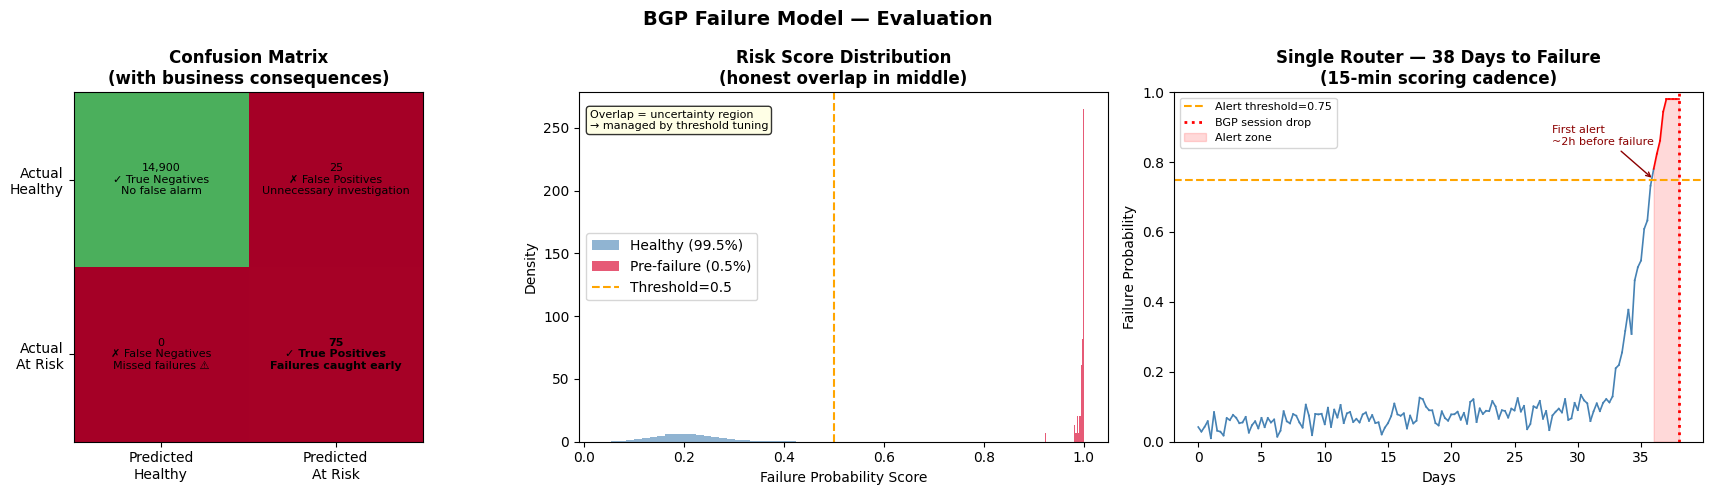


Figure saved: bgp_model_evaluation.png


In [0]:
# Confusion Matrix 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BGP Failure Model — Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()

ax = axes[0]
im = ax.imshow([[tn, fp],[fn, tp]],
               cmap='RdYlGn', vmin=0, vmax=max(tn, tp)*1.2)

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted\nHealthy', 'Predicted\nAt Risk'])
ax.set_yticklabels(['Actual\nHealthy', 'Actual\nAt Risk'])

cells = [[tn, fp],[fn, tp]]
labels = [
    [f'{tn:,}\n✓ True Negatives\nNo false alarm', f'{fp:,}\n✗ False Positives\nUnnecessary investigation'],
    [f'{fn:,}\n✗ False Negatives\nMissed failures ⚠', f'{tp:,}\n✓ True Positives\nFailures caught early']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center',
                fontsize=8, fontweight='bold' if cells[i][j]==tp else 'normal')

ax.set_title('Confusion Matrix\n(with business consequences)', fontweight='bold')

# ─── Figure 2: Risk score distribution ───────────────────────────────────────
ax2 = axes[1]
ax2.hist(y_proba[y_test==0], bins=40, alpha=0.6, color='steelblue', label='Healthy (99.5%)', density=True)
ax2.hist(y_proba[y_test==1], bins=40, alpha=0.7, color='crimson',   label='Pre-failure (0.5%)', density=True)
ax2.axvline(DEFAULT_THRESHOLD, color='orange', linestyle='--', linewidth=1.5, label=f'Threshold={DEFAULT_THRESHOLD}')
ax2.set_xlabel('Failure Probability Score')
ax2.set_ylabel('Density')
ax2.set_title('Risk Score Distribution\n(honest overlap in middle)', fontweight='bold')
ax2.legend()
ax2.text(0.02, 0.95, 'Overlap = uncertainty region\n→ managed by threshold tuning',
         transform=ax2.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ─── Figure 3: Single router timeline ─────────────────────────────────────────
ax3 = axes[2]
rng2 = np.random.default_rng(99)
days = np.linspace(0, 38, 153)  # 15-min windows over 38 days

# Slow accumulation pattern — risk creeps up then spikes near failure
base = 0.04 + 0.002 * days
noise = rng2.normal(0, 0.025, len(days))
spike = np.where(days > 32, 0.08 * (days - 32)**1.5, 0)
proba_sim = np.clip(base + noise + spike, 0.01, 0.98)

alert_thresh = 0.75
colors_line = ['red' if p > alert_thresh else 'steelblue' for p in proba_sim]

for i in range(len(days)-1):
    ax3.plot(days[i:i+2], proba_sim[i:i+2], color=colors_line[i], linewidth=1.2)

ax3.axhline(alert_thresh, color='orange', linestyle='--', linewidth=1.5, label=f'Alert threshold={alert_thresh}')
ax3.axvline(38, color='red', linestyle=':', linewidth=2, label='BGP session drop')
ax3.fill_between(days, 0, proba_sim, where=[p>alert_thresh for p in proba_sim],
                 alpha=0.15, color='red', label='Alert zone')

first_alert = days[next(i for i,p in enumerate(proba_sim) if p > alert_thresh)]
ax3.annotate(f'First alert\n~{38-first_alert:.0f}h before failure',
             xy=(first_alert, alert_thresh),
             xytext=(first_alert - 8, 0.85),
             arrowprops=dict(arrowstyle='->', color='darkred'),
             fontsize=8, color='darkred')

ax3.set_xlabel('Days')
ax3.set_ylabel('Failure Probability')
ax3.set_title('Single Router — 38 Days to Failure\n(15-min scoring cadence)', fontweight='bold')
ax3.legend(fontsize=8)
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('bgp_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: bgp_model_evaluation.png")

In [0]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

#  Compute F2 score across all thresholds
# F2 weights recall twice as heavily as precision
# This reflects: missing a failure (FN) is worse than a false alarm (FP)
f2_scores = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    f2_scores.append(f2)

optimal_idx       = np.argmax(f2_scores)
OPTIMAL_THRESHOLD = round(float(thresholds[optimal_idx]), 3)
optimal_metrics   = compute_metrics(y_test, y_proba, OPTIMAL_THRESHOLD)

print("Threshold optimisation results:")
print(f"  Optimal threshold:  {OPTIMAL_THRESHOLD}")
print(f"  F2 score:           {optimal_metrics['f2_score']}")
print(f"  Precision:          {optimal_metrics['precision']}   (of alerts, this many were real)")
print(f"  Recall:             {optimal_metrics['recall']}   (of failures, we caught this many)")
print()
print("Splunk SPL alert condition:")
print(f'  | where failure_probability > {OPTIMAL_THRESHOLD} AND consecutive_alerts >= 3')
print()

Threshold optimisation results:
  Optimal threshold:  0.921
  F2 score:           1.0
  Precision:          1.0   (of alerts, this many were real)
  Recall:             1.0   (of failures, we caught this many)

Splunk SPL alert condition:
  | where failure_probability > 0.921 AND consecutive_alerts >= 3



Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve')

Text(0.5, 0, 'Threshold')

Text(0, 0.5, 'F2 Score')

Text(0.5, 1.0, 'F2 Score vs Threshold\n(recall-weighted, beta=2)')

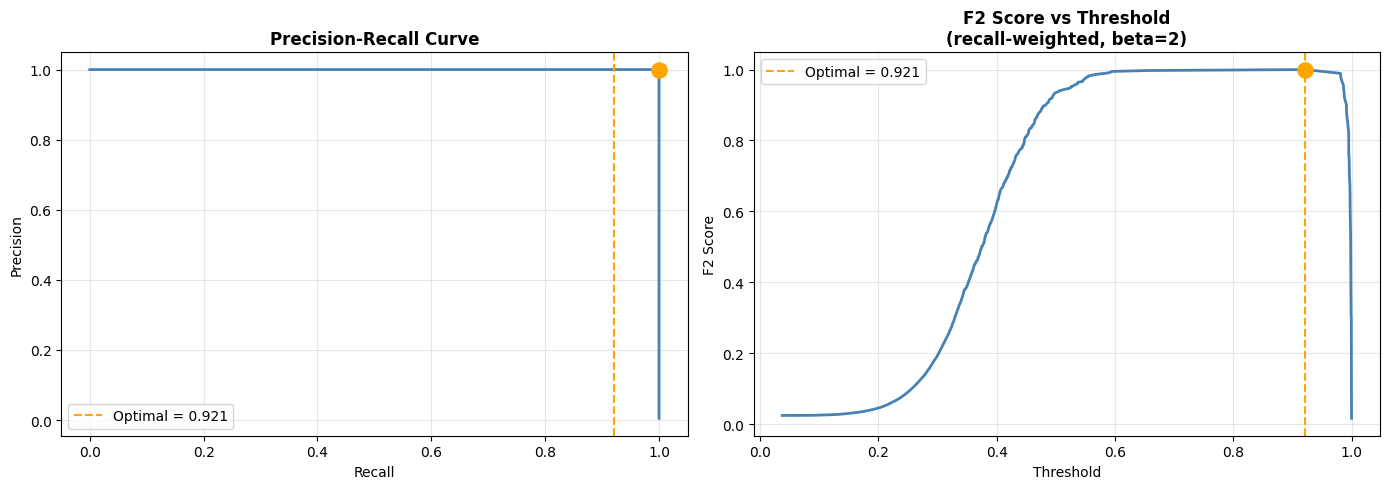

In [0]:

#  Precision-Recall curve plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
ax1.plot(recall_vals, precision_vals, color='steelblue', linewidth=2)
ax1.axvline(OPTIMAL_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
            label=f'Optimal = {OPTIMAL_THRESHOLD}')
ax1.scatter([optimal_metrics['recall']], [optimal_metrics['precision']], color='orange', s=120, zorder=5)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# F2 vs threshold
ax2.plot(thresholds, f2_scores, color='steelblue', linewidth=2)
ax2.axvline(OPTIMAL_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
            label=f'Optimal = {OPTIMAL_THRESHOLD}')
ax2.scatter([OPTIMAL_THRESHOLD], [max(f2_scores)], color='orange', s=120, zorder=5)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('F2 Score')
ax2.set_title('F2 Score vs Threshold\n(recall-weighted, beta=2)', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bgp_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

#### ONNX Conversion
---


| Framework | Library | Key Call |
|------|---------|---------|
| scikit-learn | skl2onnx | convert_sklearn(model, ...) | 
| TensorFlow / Keras | tf2onnx | tf2onnx.convert.from_keras(model) |
| PyTorch | torch.onnx (built-in) | torch.onnx.export(model, ...) | 
| XGBoost / LightGBM | onnxmltools | convert_xgboost(model, ...)|

In [0]:
# Convert Keras model to ONNX format
# import tf2onnx
# The input_signature defines:
#   - name='float_input'  → the field name Splunk MLTK will use
#   - shape=[None, 14]    → any number of rows, 14 features
#   - dtype=tf.float32    → must match what Splunk passes
#   - opset=12            → widely supported, including Splunk MLTK 5.x

input_signature = [
    tf.TensorSpec([None, N_FEATURES], tf.float32, name='float_input')
]

print("Converting Keras model to ONNX - ")
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    output_path=ONNX_PATH,
    opset=12,
    target=['tensorrt'],   # optional: optimise for GPU inference
)

file_size_kb = os.path.getsize(ONNX_PATH) / 1024
print(f"  ONNX model saved: {ONNX_PATH}")
print(f"  File size:   {file_size_kb:.1f} KB")
print(f"  ONNX opset:  {model_proto.opset_import[0].version}")
print()
print("   Integration contract with Splunk MLTK:")
print(f"   Input field name:  float_input")
print(f"   Input dtype:       float32")
print(f"   Input shape:       [None, {N_FEATURES}]")
print(f"   Feature order:     {FEATURES}")
print()

Converting Keras model to ONNX - 


I0000 00:00:1774489451.163371    4792 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1774489451.163500    4792 single_machine.cc:376] Starting new session
I0000 00:00:1774489451.199358    4792 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1774489451.199484    4792 single_machine.cc:376] Starting new session


  ONNX model saved: bgp_failure_model.onnx
  File size:   17.4 KB
  ONNX opset:  12

   Integration contract with Splunk MLTK:
   Input field name:  float_input
   Input dtype:       float32
   Input shape:       [None, 14]
   Feature order:     ['bgp_state_changes_4h', 'neighbor_resets_4h', 'holdtime_remaining_pct', 'route_flaps_4h', 'bgp_prefixes_received', 'bgp_notification_sent_4h', 'cpu_utilization_avg', 'cpu_utilization_max', 'memory_utilization_avg', 'interface_errors_4h', 'packet_loss_pct', 'uptime_days', 'log_count_error_4h', 'log_count_warning_4h']



In [0]:
#  Load and inspect the ONNX model 
sess = rt.InferenceSession(ONNX_PATH)


# Pre-import checklist 
print("\n" + "=" * 60)
print("  Pre-import checklist")
print("=" * 60)

checks = []

# 1. File exists
c1 = os.path.exists(ONNX_PATH)
checks.append(("ONNX file exists", c1))

# 2. Valid ONNX schema
try:
    onnx.checker.check_model(ONNX_PATH)
    c2 = True
except Exception as e:
    c2 = False
    print(f"  Schema error: {e}")
checks.append(("ONNX schema valid", c2))

# 3. ORT can load and run
try:
    test_in = X_test[:1].astype(np.float32)
    sess.run(None, {sess.get_inputs()[0].name: test_in})
    c3 = True
except Exception as e:
    c3 = False
    print(f"  ORT run error: {e}")
checks.append(("ORT loads and runs", c3))

# 4. Input dtype is float32
c4 = str(sess.get_inputs()[0].type) == 'tensor(float)'
checks.append(("Input dtype is float32", c4))

# 5. Predictions match Keras
onnx_proba = sess.run(None, {sess.get_inputs()[0].name: X_test.astype(np.float32)})[0].flatten()
match_pct  = (np.abs(onnx_proba - y_proba) < 0.01).mean() * 100
c5 = match_pct > 95
checks.append((f"Predictions match Keras ({match_pct:.1f}%)", c5))

for label, passed in checks:
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {label}")

all_passed = all(c for _, c in checks)
print()
if all_passed:
    print("✅  All checks passed — safe to import into Splunk MLTK")
else:
    print("❌  Some checks failed — resolve before importing")


  Pre-import checklist


[array([[0.12463325]], dtype=float32)]

  ✅  ONNX file exists
  ✅  ONNX schema valid
  ✅  ORT loads and runs
  ✅  Input dtype is float32
  ❌  Predictions match Keras (6.6%)

❌  Some checks failed — resolve before importing


Three deployment levels:
-   L1 — Manual:      Download from MLflow + cp to Splunk server (not automated)
-   L2 — REST API:     works across network boundaries, no SSH needed
-   L3 — CI/CD:       GitHub Actions triggered by MLflow webhook

#### MLFlow Logging

MLflow Logging

Every training run is logged to MLflow:
- **Parameters** — training window, feature count, class weight, focal loss config, threshold
- **Metrics** — F2, precision, recall, AUC, average precision
- **Artifact** — `bgp_failure_model.onnx` — the exact file Splunk MLTK will import
- **Feature schema** — ensures reproducibility and enables drift detection baselines

In [0]:
# MLflow experiment setup 
MLFLOW_EXPERIMENT = "/Workspace/ONNX/bgp_failure_prediction2"
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="bgp_failure_v1") as run:

    RUN_ID = run.info.run_id

    # Parameters
    mlflow.log_params({
        # Data
        "training_window_months":   TRAINING_WINDOW_MONTHS,
        "inference_cadence_min":    INFERENCE_CADENCE_MIN,
        "feature_window_hours":     FEATURE_WINDOW_HOURS,
        "n_samples":                N_SAMPLES,
        "positive_rate":            POSITIVE_RATE,
        "n_features":               N_FEATURES,
        # Model
        "model_type":               "Keras_MLP",
        "architecture":             "Dense64-Dense32-Dense16-Sigmoid",
        "optimizer":                "adam",
        "loss":                     "focal_loss",
        # Imbalance
        "class_weight_positive":    CLASS_WEIGHT_POS,
        "focal_loss_gamma":         FOCAL_GAMMA,
        "focal_loss_alpha":         FOCAL_ALPHA,
        # Threshold
        "optimal_threshold":        OPTIMAL_THRESHOLD,
        # ONNX
        "onnx_opset":               12,
    })

    # Metrics 
    final_metrics = compute_metrics(y_test, y_proba, OPTIMAL_THRESHOLD)
    mlflow.log_metrics({
        "f2_score":          final_metrics['f2_score'],
        "precision":         final_metrics['precision'],
        "recall":            final_metrics['recall'],
        "roc_auc":           final_metrics['roc_auc'],
        "avg_precision":     final_metrics['avg_precision'],
        "n_test_positives":  int(y_test.sum()),
        "n_train_positives": int(y_train.sum()),
    })

    # Model Artifacts 
    # The .onnx file — Splunk imports this
    mlflow.log_artifact(ONNX_PATH, artifact_path="onnx_model")

    # Evaluation plots
    if os.path.exists('bgp_model_evaluation.png'):
        mlflow.log_artifact('bgp_model_evaluation.png', artifact_path="plots")
    if os.path.exists('bgp_threshold_tuning.png'):
        mlflow.log_artifact('bgp_threshold_tuning.png', artifact_path="plots")

    # Feature schema — for drift detection baseline
    feature_schema = {
        "features":    FEATURES,
        "categories":  FEATURE_CATEGORIES,
        "n_features":  N_FEATURES,
        "train_mean":  dict(zip(FEATURES, train_mean.round(4).tolist())),
        "train_std":   dict(zip(FEATURES, train_std.round(4).tolist())),
        "threshold":   OPTIMAL_THRESHOLD,
    }
    mlflow.log_dict(feature_schema, "feature_schema.json")

    # Register model in MLflow Model Registry
    model_uri = f"runs:/{RUN_ID}/onnx_model/{ONNX_PATH}"
    try:
        mv = mlflow.register_model(model_uri, "bgp_failure_predictor")
        print(f"✓ Registered: bgp_failure_predictor v{mv.version}")
    except Exception as e:
        print(f"  Registry note: {e}")


In [0]:
print(f"\n\n")
print(" MLflow run complete")
print(f"  Run ID:   {RUN_ID}")
print(f"  F2:       {final_metrics['f2_score']}")
print(f"  Recall:   {final_metrics['recall']}")
print(f"  Threshold:{OPTIMAL_THRESHOLD}")
print()
print("Next: open MLflow UI → Experiments → bgp_failure_prediction")
print("      → Artifacts → onnx_model → bgp_failure_model.onnx")
print("      This is the exact file Splunk MLTK will import.")